# Figure 4, Part 2: Decision variable prediction

In [1]:
%load_ext autoreload
%autoreload 2

In [ ]:
cd "/app/"

/app


/usr/local/lib/python3.9/dist-packages/IPython/core/magics/osm.py:417: UserWarning: using dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [3]:
%run env.py
%run run.py connect

2025-02-12 09:48:44,437::INFO::settings.py::Setting loglevel to INFO
2025-02-12 09:48:44,438::INFO::settings.py::Setting stores to {}
2025-02-12 09:48:44,439::INFO::settings.py::Setting database.misc.schema_prefix to 
2025-02-12 09:48:44,440::INFO::settings.py::Setting database.misc.create_tables to True
2025-02-12 09:48:44,440::INFO::settings.py::Setting enable_python_native_blobs to True
2025-02-12 09:48:44,441::INFO::settings.py::Setting database.host to 128.178.51.167:3309
2025-02-12 09:48:44,442::INFO::settings.py::Setting database.user to celia
2025-02-12 09:48:44,442::INFO::settings.py::Setting database.password to celia
2025-02-12 09:48:44,499::INFO::connection.py::Connected celia@128.178.51.167:3309
2025-02-12 09:48:44,514::INFO::table.py::could not log event in table ~log


Connecting celia@128.178.51.167:3309


2025-02-12 09:48:44,934::INFO::table.py::could not log event in table ~log
2025-02-12 09:48:44,934::INFO::table.py::could not log event in table ~log
2025-02-12 09:48:44,947::INFO::table.py::could not log event in table ~log
2025-02-12 09:48:44,947::INFO::table.py::could not log event in table ~log
2025-02-12 09:48:44,973::INFO::table.py::could not log event in table ~log
2025-02-12 09:48:44,973::INFO::table.py::could not log event in table ~log
2025-02-12 09:48:44,994::INFO::table.py::could not log event in table ~log
2025-02-12 09:48:44,994::INFO::table.py::could not log event in table ~log


In [20]:
from vr4mice.schema.base_analysis import DataFrame
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from vr4mice.analysis import plotting
from base_schemas.schemas.exp import Session
from vr4mice.schema import base_analysis
from vr4mice.analysis.analysis import style
from vr4mice.analysis import analysis
from vr4mice.schema import dlc
from vr4mice.analysis import utils
from vr4mice.analysis import regression

from statsmodels.stats.anova import AnovaRM 
from scipy.stats import ttest_rel, ttest_ind
import scipy.stats as stats
style()

save_fig_path =  "notebooks/Paper_figures/Figure_output/"

In [5]:
# See Figure 4 B-E notebook to see how the data was generated
big_df = pd.read_pickle("big_df_contrast_multi.pkl")

In [6]:
big_df = big_df [big_df.iti ==0.0]
big_df = big_df [big_df.trial_rewarded == 1.0]

In [7]:
big_df["norm_x"] = big_df.groupby(["dataset", "trial"], as_index=False)["x"].transform(
        lambda x: x - np.mean(x.iloc[:3])
    )


big_df["flip_one_side"] = big_df["trial_left_choice"].replace([0, 1], [1, -1])
columns = [
    "norm_y",
    "norm_x",
    "heading_dir",
    "head_angle",
    "trial_tortuosity",
    "trial_duration",
    "x",
    "y",
    "aperture",
    "velocity",
    "velocity_x",
    "velocity_y",
    "trial_rewarded",
    "norm_y",
    "flip_one_side",
]
j_shaped = analysis.get_jshaped_trials(big_df)

n_samples = 500
interpolated_j_shaped = utils.interpolate(
    j_shaped, n_points=n_samples, value_columns=["trial_left_choice"] + columns
)
interpolated_j_shaped["trial_step"] = interpolated_j_shaped.groupby(
    ["dataset", "trial"], as_index=False).trial.cumcount()


interpolated_j_shaped["trial_length"] = interpolated_j_shaped["trial_step"] / n_samples
interpolated_j_shaped["head_angle_sin"] = np.sin(np.deg2rad(interpolated_j_shaped.head_angle))
interpolated_j_shaped["head_angle_cos"] = np.cos(np.deg2rad(interpolated_j_shaped.head_angle))

interpolated_j_shaped["heading_dir_sin"] = np.sin(np.deg2rad(interpolated_j_shaped.heading_dir))
interpolated_j_shaped["heading_dir_cos"] = np.cos(np.deg2rad(interpolated_j_shaped.heading_dir))

interpolated_j_shaped["velocity_x_fliped"] = (
    interpolated_j_shaped["velocity_x"] * interpolated_j_shaped["flip_one_side"]
)

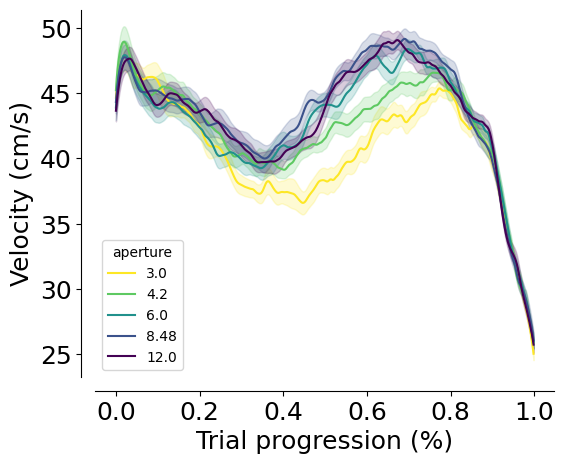

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 5))
ax = ax
mean_mouse = interpolated_j_shaped.groupby(
    ["dataset", "aperture", "trial_length"], as_index=False
).mean(numeric_only=True)

label = "velocity"
sns.lineplot(
        data=mean_mouse,
        x="trial_length",
        y="velocity",
        palette=plotting.colors_multi_aperture,
        hue="aperture",
        errorbar="se",
        ax=ax,
    )

sns.despine(offset=10)
ax.set_xlabel("Trial progression (%)")
ax.set_ylabel("Velocity (cm/s)")
plt.tight_layout(pad=2)
plt.savefig(save_fig_path + "multi_occluder_veloctiy.svg", transparent=False)



In [9]:
model_labels = [
    "x",
    "y",
    "velocity_x",
    "velocity_y",
    "heading_dir_sin",
    "heading_dir_cos",
    "head_angle_sin",
    "head_angle_cos",
    "trial_tortuosity",
    #"trial_duration",
    #"aperture",
    "trial_rewarded",
    "trial_length",
]


clean_model_labels = [
    'x position',
    'y position',
    'x velocity',
    'y velocity',
    'sin(running direction)',
    'cos(running direction)',
    'sin(head-body angle)',
    'cos(head-body angle)',
    'Trial tortuosity',
    'Trial rewarded',
    'Trial progression'
]

In [10]:
interpolated_j_shaped["aperture"] = interpolated_j_shaped["aperture"].astype(float)

df_model, coef = regression.predict_decision(
    df=interpolated_j_shaped, label=model_labels, per_mouse=True)

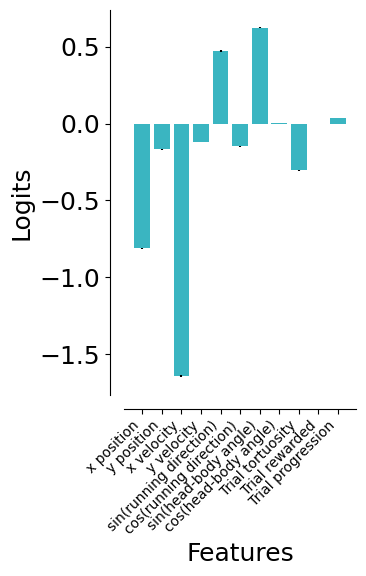

In [40]:
# Logits of the regression
fig, ax = plt.subplots(1, 1, figsize=(3, 5))
ax.bar(
    model_labels,
    np.mean(coef[:, 1:], axis=0),
    yerr=stats.sem(coef[:, 1:], axis=0),
    color="#3AB5C1"
)
sns.despine(offset=10, ax=ax)

ax.set_xticks(np.arange(len(model_labels))) 
ax.set_xticklabels(clean_model_labels, rotation=45, ha="right", fontsize=10)
ax.set_ylabel("Logits")
ax.set_xlabel("Features")

plt.savefig(save_fig_path + "multi_occluder_model_logits.svg", transparent=False)

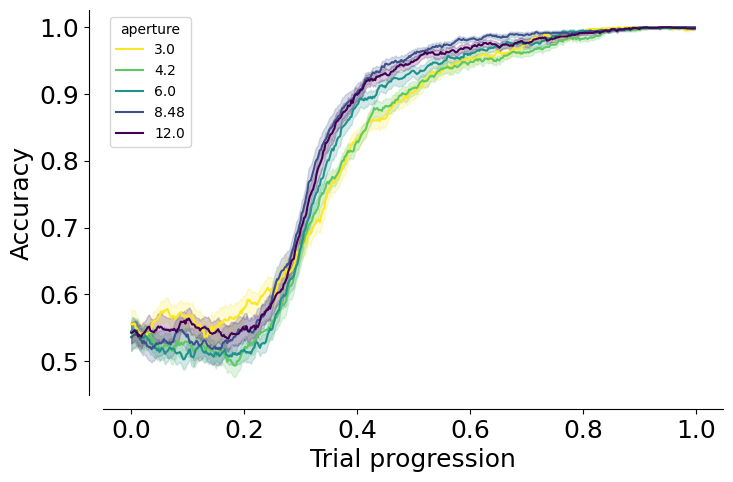

In [11]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

mean_mouse = df_model.groupby(["dataset", "aperture", "trial_length"]).mean(
    numeric_only=True
)

mean_mouse_per_choice = df_model.groupby(
    ["dataset", "trial_left_choice", "aperture", "trial_length"]
).mean(numeric_only=True)

# Accuracy
sns.lineplot(
    ax=ax,
    data=mean_mouse,
    y="accuracy",
    x="trial_length",
    hue="aperture",
    palette=plotting.colors_multi_aperture,
    errorbar="se",
)
sns.despine(offset=10)
ax.set_xlabel("Trial progression")
ax.set_ylabel("Accuracy")
#percentile = np.percentile(mean_mouse_model_shuff.accuracy, 95)
plt.savefig(save_fig_path + "multi_occluder_model_accuracy.svg", transparent=False)


In [12]:
df_model ["session"] = df_model ["dataset"]
df_model ["trial_L_choice"] = df_model ["trial_left_choice"]
decision_points = regression.find_decision_point(df_model, threshold_uncertainty=0.3)

2025-02-12 09:51:07,151::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 09:51:07,151::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 09:51:07,156::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 09:51:07,156::INFO::category.py::Using categorical units to plot a list of strings that are all parsable as floats or dates. If these strings should be plotted as numbers, cast to the appropriate data type before plotting.
2025-02-12 09:51:07,216::INFO::category.py::Using categorical un

3.0-4.2: TtestResult(statistic=4.072449065435792, pvalue=0.0005054599394518282, df=22)
3.0-6.0: TtestResult(statistic=5.324320080968275, pvalue=2.411026254833839e-05, df=22)
3.0-8.48: TtestResult(statistic=11.291230989371877, pvalue=1.268075148170175e-10, df=22)
4.2-6.0: TtestResult(statistic=3.4450950723936917, pvalue=0.0023086512977279045, df=22)
4.2-8.48: TtestResult(statistic=6.898066628106478, pvalue=6.300658507606434e-07, df=22)
6.0-8.48: TtestResult(statistic=3.6240410829430116, pvalue=0.0015018532994096132, df=22)
12.0-3.0: TtestResult(statistic=-11.22173398083199, pvalue=1.4248403767402893e-10, df=22)
12.0-4.2: TtestResult(statistic=-7.9294364592968885, pvalue=6.836425655155669e-08, df=22)
12.0-6.0: TtestResult(statistic=-5.898915803069249, pvalue=6.171873617617189e-06, df=22)
12.0-8.48: TtestResult(statistic=-1.4817443193947024, pvalue=0.15259079710455717, df=22)


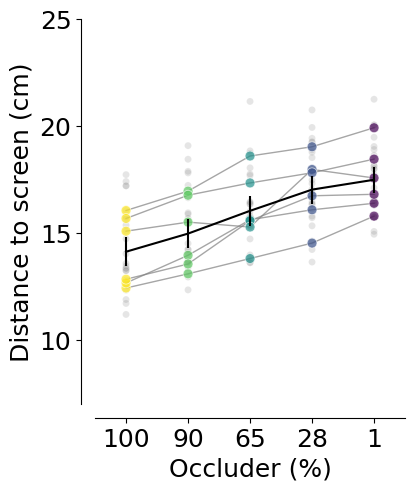

In [13]:
fig, ax = plt.subplots(1, 1, figsize=(4, 5))
stats = plotting.pairplot_average_decision_point(decision_points, 
                                                 label_parameter="y",  
                                                 ax=ax, 
                                                 cmap=plotting.colors_multi_aperture,
                                                 per_mouse=True)
ax.set_ylim(7,25)
ax.set_xlim(-.5,4.5)
ax.set_xticks([0,1,2,3,4], ["100", "90", "65", "28", "1"])
plt.legend([],[], frameon=False)
sns.despine(offset=10)

plt.savefig(save_fig_path + "multi_occluder_decision_points.svg", transparent=True)

In [14]:
decision_points = decision_points.groupby(["dataset", "aperture"], as_index=False)["y"].mean()
anova_rm = AnovaRM(decision_points, depvar='y', subject='dataset', within=['aperture'])

anova_results = anova_rm.fit()
anova_table = anova_results.summary()
print(anova_table)

                Anova
         F Value Num DF  Den DF Pr > F
--------------------------------------
aperture 47.5261 4.0000 88.0000 0.0000



In [15]:
trials_by_time = interpolated_j_shaped.groupby(["aperture", "trial_step", "trial_left_choice"], as_index=False)[["x", "y"]].mean()

<Axes: xlabel='x', ylabel='y'>

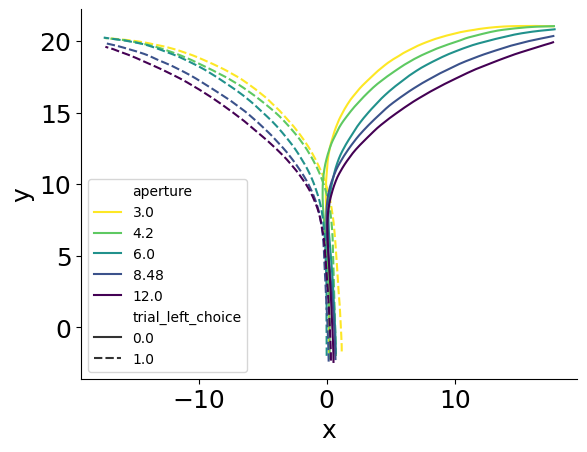

In [16]:
sns.lineplot(trials_by_time, 
             x="x", 
             y="y", 
             hue="aperture", 
             style="trial_left_choice", 
             palette=plotting.colors_multi_aperture, 
             sort=False, 
             alpha=1)